In [143]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler , MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [144]:
superstore_df = pd.read_csv('SuperStoreOrders.csv')
superstore_df.head(10)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011
5,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Paper,"Eaton Computer Printout Paper, 8.5",55,2,0.1,15.342,1.80,Medium,2011
6,CA-2011-1510,2/1/2011,6/1/2011,Standard Class,Magdelene Morse,Consumer,Ontario,Canada,Canada,Canada,...,Technology,Machines,"Okidata Inkjet, Wireless",314,1,0.0,3.120,24.10,Medium,2011
7,IN-2011-79397,3/1/2011,3/1/2011,Same Day,Kean Nguyen,Corporate,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Appliances,"Hoover Microwave, White",276,1,0.1,110.412,125.32,Critical,2011
8,ID-2011-80230,3/1/2011,9/1/2011,Standard Class,Ken Lonsdale,Consumer,Auckland,New Zealand,APAC,Oceania,...,Technology,Copiers,"Hewlett Wireless Fax, Laser",912,4,0.4,-319.464,107.10,Low,2011
9,IZ-2011-4680,3/1/2011,7/1/2011,Standard Class,Lindsay Williams,Corporate,Ninawa,Iraq,EMEA,EMEA,...,Furniture,Chairs,"Novimex Swivel Stool, Set of Two",667,4,0.0,253.320,81.26,High,2011


In [145]:
superstore_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [146]:
superstore_df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [147]:
superstore_df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [148]:
superstore_df.duplicated().sum()

np.int64(0)

In [149]:
superstore_df['sales'] = superstore_df['sales'].str.replace(',', '', regex=False).astype(float)

In [150]:
num_cols = superstore_df.select_dtypes(include=['int64', 'float64']).columns
df = superstore_df.copy()

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print(df.shape)
superstore_df.shape

(30883, 21)


(51290, 21)

In [151]:
x = df[['category',
        'sub_category',
        'region',
        'state',
        'segment',
        'quantity',
        'discount',
        'shipping_cost',
        'ship_mode',
        'market',
        'order_priority',
        'year']]
x.head()

,category,sub_category,region,state,segment,quantity,discount,shipping_cost,ship_mode,market,order_priority,year
1,Office Supplies,Supplies,Oceania,New South Wales,Consumer,3,0.1,9.72,Standard Class,APAC,Medium,2011
2,Office Supplies,Storage,EMEA,Budapest,Consumer,4,0.0,8.17,Second Class,EMEA,High,2011
3,Office Supplies,Paper,North,Stockholm,Home Office,3,0.5,4.82,Second Class,EU,High,2011
4,Furniture,Furnishings,Oceania,New South Wales,Consumer,5,0.1,4.70,Standard Class,APAC,Medium,2011
5,Office Supplies,Paper,Oceania,New South Wales,Consumer,2,0.1,1.80,Standard Class,APAC,Medium,2011


In [152]:

y = df['sales']
y.head()

1    120.0
2     66.0
3     45.0
4    114.0
5     55.0
Name: sales, dtype: float64

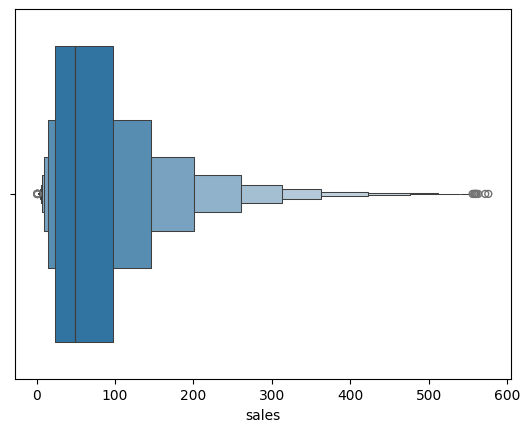

In [153]:
sns.boxenplot(data = df,x='sales')
plt.show()

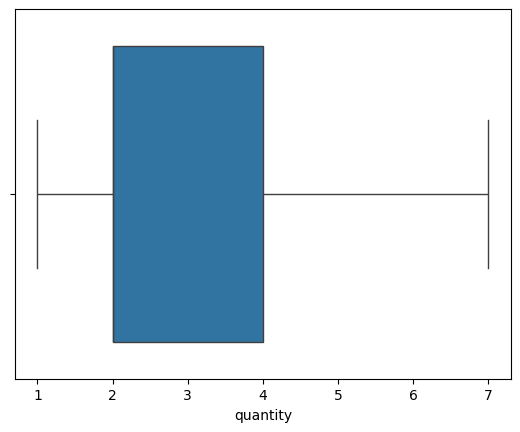

In [154]:
sns.boxplot(data=df, x='quantity')
plt.show()

In [155]:
ss = StandardScaler()
ss.fit_transform(x[['quantity']])

array([[ 0.09381107],
       [ 0.7186045 ],
       [ 0.09381107],
       ...,
       [ 0.09381107],
       [-1.15577579],
       [ 0.09381107]], shape=(30883, 1))

In [156]:
ms = MinMaxScaler()
ms.fit_transform(x[['quantity']])

array([[0.33333333],
       [0.5       ],
       [0.33333333],
       ...,
       [0.33333333],
       [0.        ],
       [0.33333333]], shape=(30883, 1))

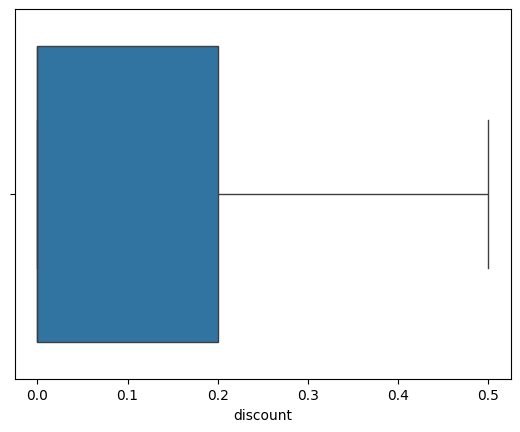

In [157]:
sns.boxplot(data=x, x='discount')
plt.show()

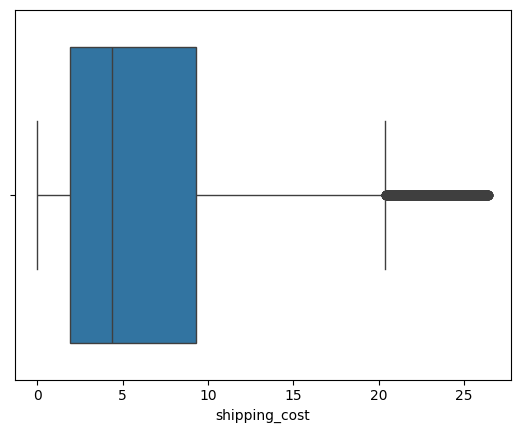

In [158]:
sns.boxplot(data=x, x='shipping_cost')
plt.show()

In [159]:
le = LabelEncoder()

categorical = [
    'category',
    'sub_category',
    'region',
    'state',
    'segment',
    'ship_mode',
    'market',
    'order_priority'
]

for col in categorical:
    x[col] = le.fit_transform(x[col])

C:\Users\Admin\AppData\Local\Temp\ipykernel_18044\3396528362.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[col] = le.fit_transform(x[col])
C:\Users\Admin\AppData\Local\Temp\ipykernel_18044\3396528362.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[col] = le.fit_transform(x[col])
C:\Users\Admin\AppData\Local\Temp\ipykernel_18044\3396528362.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead


In [160]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [161]:
x_train

,category,sub_category,region,state,segment,quantity,discount,shipping_cost,ship_mode,market,order_priority,year
9382,1,2,0,861,0,1,0.00,5.54,0,1,1,2012
1081,1,1,3,548,0,2,0.00,4.10,3,6,3,2011
1593,1,10,0,559,2,1,0.00,0.35,2,1,1,2011
7083,0,4,0,601,0,2,0.00,24.59,3,1,1,2011
30981,1,8,11,919,2,1,0.17,0.74,3,0,3,2013
...,...,...,...,...,...,...,...,...,...,...,...,...
49531,1,3,9,700,0,6,0.10,8.78,3,0,3,2014
8988,1,2,3,553,1,7,0.00,5.60,3,6,1,2011
1421,1,2,3,544,0,4,0.00,6.63,3,6,3,2011
26274,1,2,7,704,2,5,0.00,2.10,3,5,3,2013


In [162]:
x_test

,category,sub_category,region,state,segment,quantity,discount,shipping_cost,ship_mode,market,order_priority,year
10696,1,2,6,598,2,2,0.00,0.20,3,6,3,2012
51083,0,4,7,574,2,1,0.20,9.54,3,5,1,2014
21148,1,14,0,207,0,1,0.00,1.30,3,1,1,2013
23035,1,2,3,614,2,1,0.00,7.24,1,4,0,2013
14428,1,3,3,687,0,2,0.00,4.46,0,4,3,2012
...,...,...,...,...,...,...,...,...,...,...,...,...
39744,1,2,5,358,0,1,0.00,5.35,0,3,3,2014
17197,1,8,10,83,0,7,0.00,6.26,3,5,3,2012
38860,2,13,11,919,1,3,0.17,23.79,3,0,3,2014
40603,2,13,5,839,0,1,0.00,7.23,2,3,3,2014


In [163]:
y_train

9382      47.0
1081      94.0
1593      10.0
7083     297.0
30981     12.0
         ...  
49531     92.0
8988      30.0
1421      79.0
26274     41.0
39279     27.0
Name: sales, Length: 24706, dtype: float64

In [164]:
ms = MinMaxScaler()
num_cols = ['quantity', 'discount', 'shipping_cost', 'year']
x_train[num_cols] = ms.fit_transform(x_train[num_cols])
x_test[num_cols] = ms.transform(x_test[num_cols])

In [165]:
lr = LinearRegression()

lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [166]:
y_pred = lr.predict(x_test)
y_pred

array([ 29.36165585,  74.1081035 ,   7.89264297, ..., 257.24574791,
        90.05789629,  88.56494191], shape=(6177,))

In [167]:
result = pd.DataFrame({
    'Actual Sales': y_test,
    'Predicted Sales': y_pred
})

print(result.head(10))

       Actual Sales  Predicted Sales
10696          11.0        29.361656
51083          91.0        74.108104
21148          17.0         7.892643
23035          22.0        24.377103
14428          63.0        46.316959
16972          22.0        -6.283089
8615           65.0        82.701178
49560          36.0        50.353774
19999         217.0       136.211453
37731         163.0        65.503677


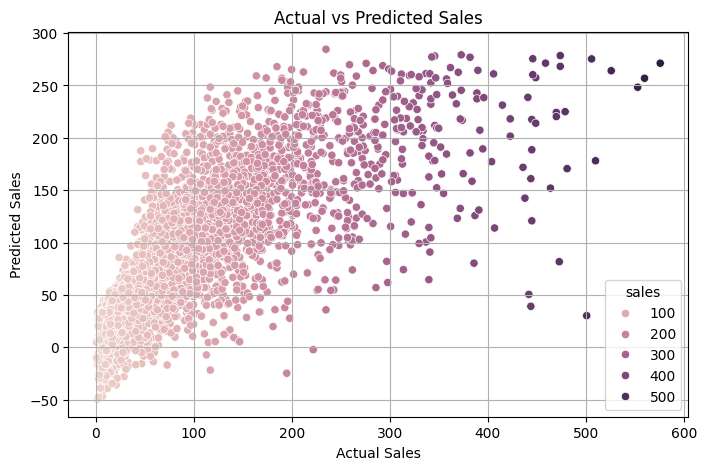

In [168]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=y_test, y=y_pred, hue=y_test)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.grid(True)

plt.show()

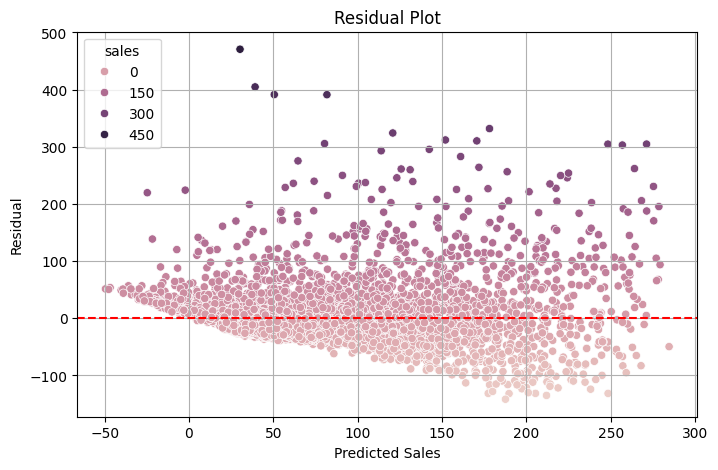

In [169]:
residual = y_test - y_pred

plt.figure(figsize=(8,5))

sns.scatterplot(x=y_pred, y=residual, hue=residual)

plt.axhline(y=0, color='red', linestyle='--')

plt.title("Residual Plot")
plt.xlabel("Predicted Sales")
plt.ylabel("Residual")

plt.grid(True)

plt.show()

In [170]:
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score :", r2_score(y_test, y_pred))

MAE : 28.180476227507754
MSE : 2026.6389346952383
RMSE : 45.01820670234698
R2 Score : 0.6316533600085195


In [171]:
coef = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': lr.coef_
})

print(coef)

           Feature  Coefficient
0         category     3.102760
1     sub_category     0.138170
2           region    -0.036014
3            state    -0.001482
4          segment    -0.154219
5         quantity    15.220168
6         discount    -3.843740
7    shipping_cost   245.240729
8        ship_mode     8.135492
9           market    -0.705489
10  order_priority    17.567070
11            year    -0.882827


In [172]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(x_train, y_train)

y_pred_dt = dt.predict(x_test)

In [173]:
print("MAE :", mean_absolute_error(y_test, y_pred_dt))
print("MSE :", mean_squared_error(y_test, y_pred_dt))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R2 Score :", r2_score(y_test, y_pred_dt))

MAE : 29.80071231989639
MSE : 2848.0898494414764
RMSE : 53.36749806241132
R2 Score : 0.4823526241030355


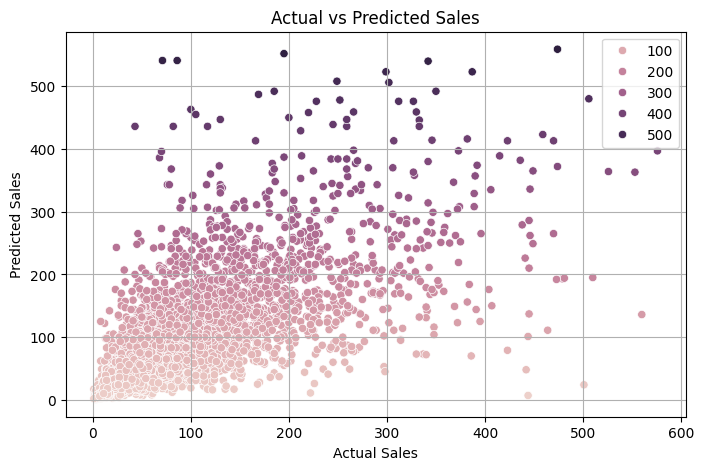

In [174]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=y_test, y=y_pred_dt, hue=y_pred_dt)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.grid(True)

plt.show()

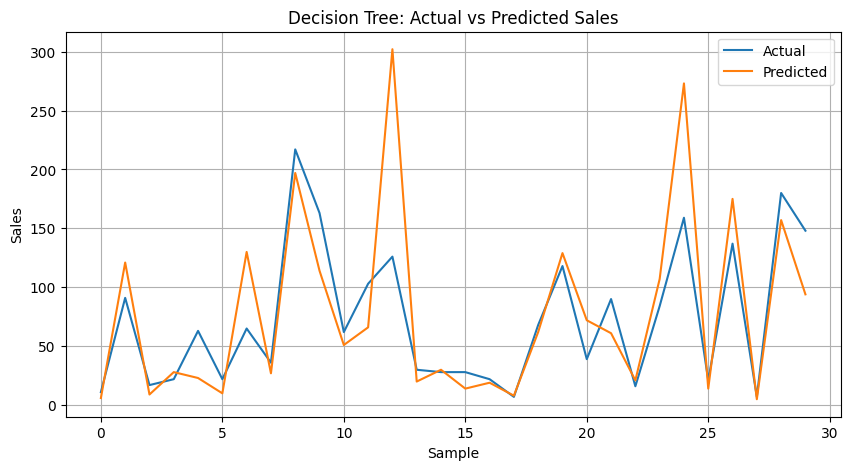

In [175]:
result = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred_dt
}).reset_index(drop=True)

plt.figure(figsize=(10,5))

sns.lineplot(data=result.head(30), x=result.head(30).index, y='Actual Sales', label='Actual')
sns.lineplot(data=result.head(30), x=result.head(30).index, y='Predicted Sales', label='Predicted')

plt.title("Decision Tree: Actual vs Predicted Sales")
plt.xlabel("Sample")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

In [ ]:
rf = RandomForestRegressor(random_state=42)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

In [ ]:
print("MAE :", mean_absolute_error(y_test, y_pred_rf))
print("MSE :", mean_squared_error(y_test, y_pred_rf))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score :", r2_score(y_test, y_pred_rf))

MAE : 21.82586554062562
MSE : 1513.2553635784861
RMSE : 38.90058307504511
R2 Score : 0.7249620940954424


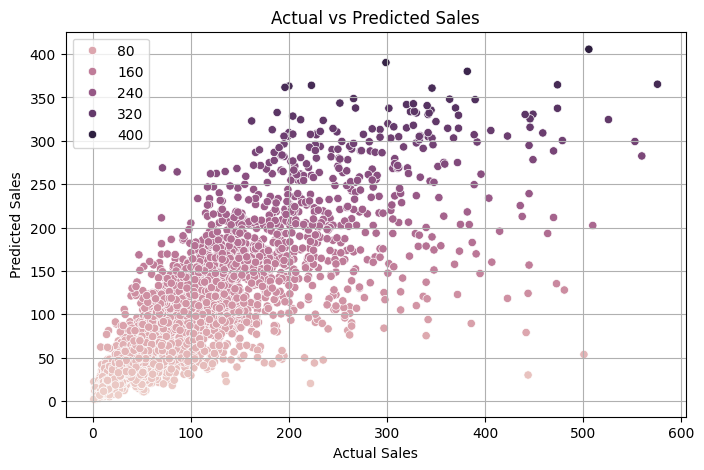

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=y_test, y=y_pred_rf, hue=y_pred_rf)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.grid(True)

plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, y_pred_dt),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, y_pred_dt)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ],
    "R2 Score": [
        r2_score(y_test, y_pred),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf)
    ]
})

print(comparison)

               Model        MAE       RMSE  R2 Score
0  Linear Regression  28.180476  45.018207  0.631653
1      Decision Tree  29.800712  53.367498  0.482353
2      Random Forest  21.825866  38.900583  0.724962


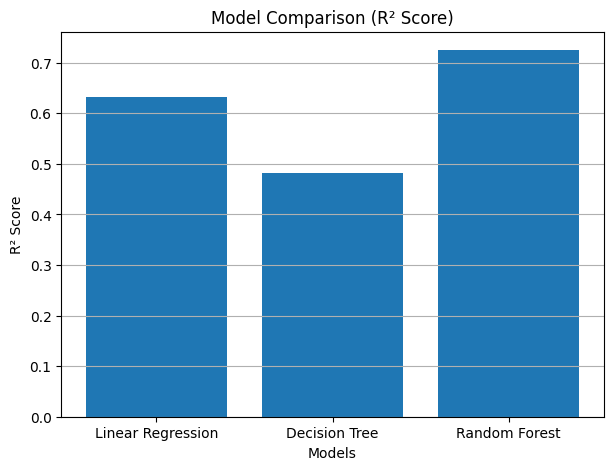

In [ ]:
models = ['Linear Regression', 'Decision Tree', 'Random Forest']
r2 = [0.631653, 0.482353, 0.724962]

plt.figure(figsize=(7,5))
plt.bar(models, r2)
plt.title("Model Comparison (R² Score)")
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.grid(axis='y')
plt.show()

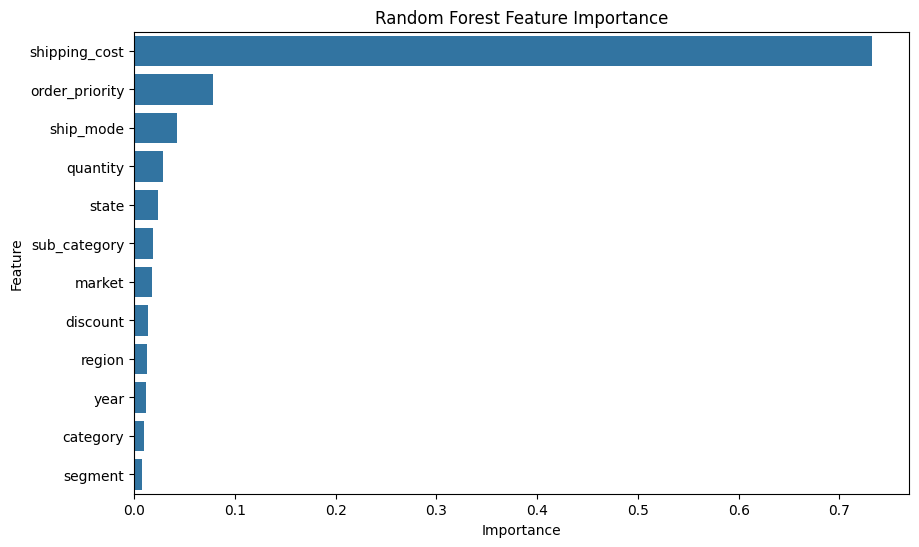

In [ ]:
importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(data=importance, x="Importance", y="Feature")

plt.title("Random Forest Feature Importance")

plt.show()